In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from adjustText import adjust_text
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import textwrap
import re
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import warnings
import networkx as nx

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.patheffects as pe
from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from sklearn.manifold import MDS
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time

# Load and aggregate pseudotime data
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/three_libraries.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 1.48 s, sys: 2.64 s, total: 4.11 s
Wall time: 7.69 s


AnnData object with n_obs × n_vars = 21062 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mito', 'filter_pass'
    uns: 'deg', 'rank_genes_groups', 'scvi_expression', 'subgroup_colors'
    obsm: 'X_paga', 'X_pca', 'X_pca_harmony', 'X_scvi

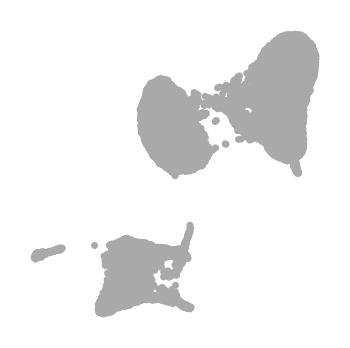

In [182]:
plt.rcParams['figure.dpi']    = 200
plt.rcParams['figure.figsize'] = 2, 2

sc.pl.umap(
    adata[adata.obs['filter_pass'], :],
    frameon=False,
    na_color='darkgrey',
    s=25,
)

In [3]:
adata.obs['group'].value_counts()

group
intial       9039
reprogram    6565
bm_other     3952
target       1506
Name: count, dtype: int64

# Distances

In [120]:
xdata = adata[adata.obs['group'] == 'reprogram', :]
X = xdata.obsm['X_scvi']
print(f"{X.shape=}")

df = xdata.obs.copy()

dist_columns = []

for y_label in ['intial', 'target']:
    ydata = adata[adata.obs['group'] == y_label, :]
    Y = ydata.obsm['X_scvi']
    dists = pairwise_distances(X=X, Y=Y, metric='euclidean')

    column_name = f"{y_label}"
    dist_columns.append(column_name)
    dists = pairwise_distances(X=X, Y=Y, metric='euclidean')
    df[column_name] = dists.mean(axis=1)

df[dist_columns].head()

X.shape=(6565, 24)


,intial,target
AAACCCAAGGTTACCT-1-fibroblasts,4.394323,4.574523
AAACCCAAGTTGAAGT-1-fibroblasts,4.753564,4.091939
AAACCCACAGGAGGTT-1-fibroblasts,6.017592,5.623299
AAACCCAGTACCTAAC-1-fibroblasts,3.985722,5.075222
AAACCCATCAGGACGA-1-fibroblasts,5.260595,5.214275


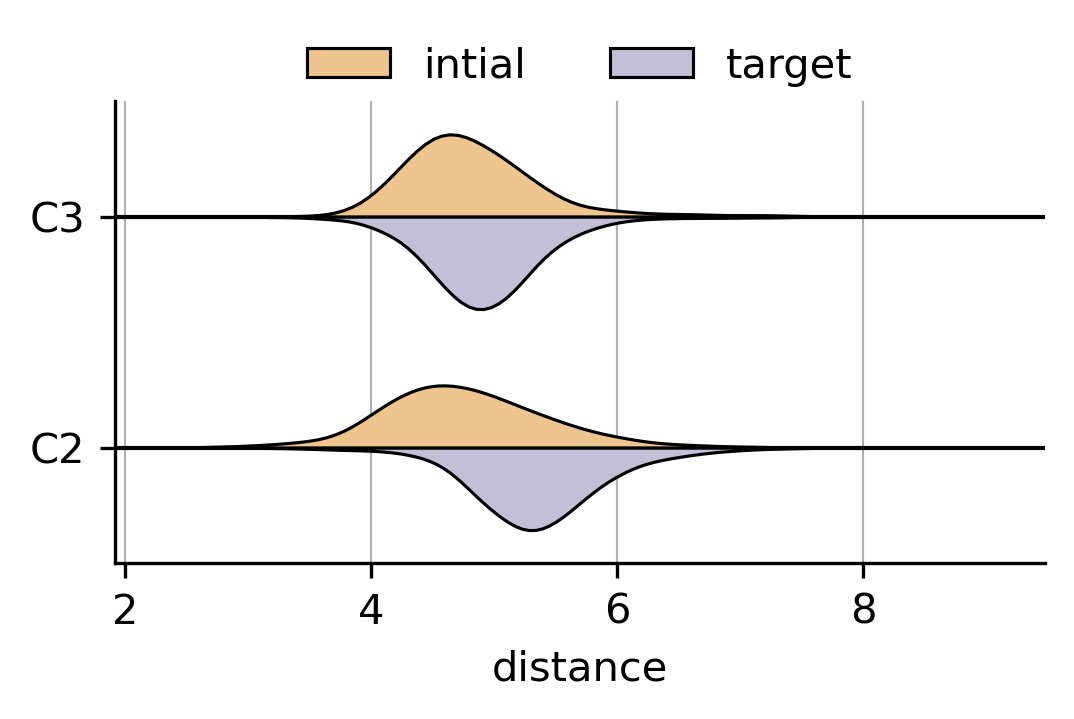

In [195]:
pdf = df.copy()
pdf = pdf[pdf['cluster'] != 'C1']
pdf['cluster'] = pdf['cluster'].astype(str)

pdf = pd.melt(
    pdf, id_vars='cluster',
    value_vars=dist_columns
)

import matplotlib.ticker as mticker

plt.rcParams['figure.dpi']    = 300
plt.rcParams['figure.figsize'] = 4, 2

fig, ax = plt.subplots()

sns.violinplot(
    data=pdf,
    y='cluster',         # was y
    x='value',           # was x
    hue='variable',
    inner=None,
    # inner='quart',
    # legend=False,
    bw_adjust=1.5,
    common_norm=True,
    linecolor='k',
    palette='PuOr',
    linewidth=0.75,
    split=True,
    zorder=2,
    ax=ax
)

# grid
ax.grid(axis='x', lw=0.5, zorder=0)
ax.grid(axis='y', lw=1, c='k', zorder=0)

# increase # of y‐ticks
# ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=8))

# relabel
ax.set_xlabel('distance')
ax.set_ylabel('')

sns.move_legend(
    ax, loc='upper center',
    ncols=2,
    title="",
    bbox_to_anchor=(0.5, 1.2),
    frameon=False,
    
)
sns.despine(ax=ax)
plt.show()




In [4]:
%%time
level  = 'group'
X = adata.obsm['X_scvi']
print(f"{X.shape=}")

dists = pairwise_distances(X, metric='euclidean')
print(f"{dists.shape=}")

df = pd.DataFrame(
    dists, 
    index=adata.obs[level].values,
    columns=adata.obs[level].values,
)
df = (df - df.values.min()) / (df.values.max() - df.values.min())
print(f"{df.shape=}")

df.head()

X.shape=(21062, 24)
dists.shape=(21062, 21062)
df.shape=(21062, 21062)
CPU times: user 1.17 s, sys: 1.43 s, total: 2.6 s
Wall time: 2.63 s


,bm_other,bm_other,bm_other,target,bm_other,bm_other,target,bm_other,bm_other,target,...,intial,intial,intial,intial,intial,intial,intial,intial,reprogram,intial
bm_other,0.000000,0.277968,0.321316,0.364093,0.279105,0.152648,0.343995,0.263461,0.192534,0.384523,...,0.275883,0.326313,0.293941,0.339328,0.395919,0.327109,0.298840,0.422050,0.269837,0.309824
bm_other,0.277968,0.000000,0.291732,0.311159,0.306427,0.360772,0.247466,0.239125,0.385287,0.328037,...,0.329886,0.371118,0.314151,0.408129,0.401595,0.340935,0.365760,0.417226,0.240496,0.297035
bm_other,0.321316,0.291732,0.000000,0.111523,0.091934,0.443730,0.128915,0.162562,0.481868,0.118769,...,0.301680,0.314837,0.307893,0.317651,0.298004,0.316821,0.354092,0.339527,0.290406,0.338225
target,0.364093,0.311159,0.111523,0.000000,0.132489,0.493174,0.080604,0.170841,0.531568,0.034125,...,0.268576,0.290500,0.277558,0.298427,0.254057,0.300199,0.339092,0.330889,0.266450,0.312789
bm_other,0.279105,0.306427,0.091934,0.132489,0.000000,0.404059,0.156464,0.154902,0.444529,0.144923,...,0.255437,0.297491,0.276431,0.280569,0.295864,0.308077,0.316248,0.350387,0.267880,0.327866
